In [1]:
import json
import re
import sys
import time
from transformers import (
    AutoModelForSequenceClassification, 
    AutoTokenizer, 
    Trainer, 
    TrainingArguments, 
    DataCollatorWithPadding,
    TrainerCallback
)
from datasets import load_from_disk
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
CLASS_WEIGHTS_PATH = "/kaggle/input/datasets/shubhamnegi1247/cysecbert/data/class_weights.json"  # adjust if this is under /kaggle/input

with open(CLASS_WEIGHTS_PATH, "r") as f:
    class_weights = json.load(f)

labels = sorted(class_weights.keys())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

label_names = labels

print("Num labels:", len(labels))
print(label2id)

Num labels: 15
{'BENIGN': 0, 'Bot': 1, 'DDoS': 2, 'DoS GoldenEye': 3, 'DoS Hulk': 4, 'DoS Slowhttptest': 5, 'DoS slowloris': 6, 'FTP-Patator': 7, 'Heartbleed': 8, 'Infiltration': 9, 'PortScan': 10, 'SSH-Patator': 11, 'Web Attack – Brute Force': 12, 'Web Attack – Sql Injection': 13, 'Web Attack – XSS': 14}


In [3]:
MODEL_PATH = "/kaggle/input/datasets/shubhamnegi1247/output/final_cysecbert_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, num_labels=len(labels), label2id=label2id, id2label=id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [4]:
test_ds = load_from_disk("/kaggle/input/datasets/shubhamnegi1247/cysecbert/data/test_dataset")

print(test_ds)
print(test_ds.column_names)
print(test_ds[0])

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'label'],
    num_rows: 281103
})
['input_ids', 'token_type_ids', 'attention_mask', 'label']
{'input_ids': [101, 20024, 22025, 1012, 1014, 3770, 1012, 1014, 1020, 1012, 1014, 6391, 22907, 24096, 11387, 1012, 1014, 1020, 1012, 1014, 1020, 1012, 1014, 24030, 1012, 1014, 10630, 2683, 2629, 1012, 1014, 24030, 1012, 1014, 1014, 1012, 1014, 5187, 1012, 1019, 14677, 1012, 5840, 2581, 19841, 12521, 4724, 22932, 1012, 1014, 1014, 1012, 1014, 4673, 1012, 1019, 22593, 1012, 6640, 16932, 2581, 2509, 15471, 1012, 28048, 23777, 2509, 1014, 1012, 16087, 23499, 2683, 19317, 2620, 6146, 16086, 2683, 11387, 1012, 1014, 22234, 8889, 8889, 2692, 1012, 1014, 6391, 18613, 8889, 2692, 1012, 1014, 1015, 1012, 1014, 6391, 18613, 8889, 2692, 1012, 1014, 24621, 8889, 8889, 1012, 1014, 4261, 16086, 8889, 8889, 1012, 1014, 6391, 18613, 8889, 2692, 1012, 1014, 1015, 1012, 1014, 15028, 24434, 2549, 1012, 1014, 25113, 2581, 2549, 1012, 1022, 51

In [5]:
def on_the_fly_transform(batch):
    # This runs only on the small batches requested during training
    batch["labels"] = [label2id[label] for label in batch["label"]]
    # Remove the original string label so the collator doesn't try to tensorize it!
    if "label" in batch:
        del batch["label"]
        
    return batch


test_ds.set_transform(on_the_fly_transform)

In [6]:

def _safe_metric_name(name: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_]+", "_", name).strip("_").lower()

def compute_metrics(eval_pred):
    logits, true_labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    num_labels = len(id2label)
    all_label_ids = list(range(num_labels))

    acc = accuracy_score(true_labels, preds)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        true_labels,
        preds,
        labels=all_label_ids,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        true_labels,
        preds,
        labels=all_label_ids,
        average="weighted",
        zero_division=0
    )

    _, per_class_recall, _, _ = precision_recall_fscore_support(
        true_labels,
        preds,
        labels=all_label_ids,
        average=None,
        zero_division=0
    )

    metrics = {
        "accuracy": acc,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted,
    }

    for i, rec in enumerate(per_class_recall):
        safe_name = _safe_metric_name(id2label[i])
        metrics[f"recall_{safe_name}"] = rec

    return metrics

In [7]:
class ProgressLogCallback(TrainerCallback):
    def __init__(self, log_every_minutes=5):
        self.log_every = log_every_minutes * 60
        self.last_log = time.time()
        self.start_time = time.time()
        self.steps = 0

    def on_prediction_step(self, args, state, control, **kwargs):
        self.steps += 1
        now = time.time()
        if now - self.last_log >= self.log_every:
            elapsed = (now - self.start_time) / 60
            print(f"[Predict] Steps done: {self.steps} | Elapsed: {elapsed:.1f} min", flush=True)
            sys.stdout.flush()
            self.last_log = now

    def on_predict_begin(self, args, state, control, **kwargs):
        self.start_time = time.time()
        self.steps = 0
        self.last_log = time.time()
        print("[Predict] Starting prediction...", flush=True)

    def on_predict_end(self, args, state, control, **kwargs):
        total = (time.time() - self.start_time) / 60
        print(f"[Predict] Done! Total steps: {self.steps} | Total time: {total:.1f} min", flush=True)

In [8]:

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)

test_args = TrainingArguments(
    output_dir="/kaggle/working/test_outputs",
    per_device_eval_batch_size=32,
    fp16=True,
    report_to="none",
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
    log_level="info",
    disable_tqdm=True,
    remove_unused_columns=True
)

test_trainer = Trainer(
    model=model,
    args=test_args,
    eval_dataset=test_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[ProgressLogCallback()]
)

In [9]:
pred_output = test_trainer.predict(test_ds)

y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=-1)

target_names = [id2label[i] for i in range(len(id2label))]


***** Running Prediction *****
  Num examples = 281103
  Batch size = 64
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


[Predict] Steps done: 411 | Elapsed: 5.0 min
[Predict] Steps done: 749 | Elapsed: 10.0 min
[Predict] Steps done: 1089 | Elapsed: 15.0 min
[Predict] Steps done: 1426 | Elapsed: 20.0 min
[Predict] Steps done: 1765 | Elapsed: 25.0 min
[Predict] Steps done: 2104 | Elapsed: 30.0 min
[Predict] Steps done: 2442 | Elapsed: 35.1 min
[Predict] Steps done: 2783 | Elapsed: 40.1 min
[Predict] Steps done: 3119 | Elapsed: 45.1 min
[Predict] Steps done: 3457 | Elapsed: 50.1 min
[Predict] Steps done: 3800 | Elapsed: 55.1 min
[Predict] Steps done: 4258 | Elapsed: 60.1 min


In [10]:
report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(target_names))),
    target_names=target_names,
    zero_division=0,
    digits=4
)

print(report)

                            precision    recall  f1-score   support

                    BENIGN     0.9991    0.9991    0.9991    226199
                       Bot     0.7945    0.8878    0.8386       196
                      DDoS     0.9988    0.9994    0.9991     12803
             DoS GoldenEye     0.9875    0.9961    0.9918      1030
                  DoS Hulk     0.9974    0.9993    0.9983     22257
          DoS Slowhttptest     0.9594    0.9873    0.9731       550
             DoS slowloris     0.9630    0.9931    0.9778       577
               FTP-Patator     0.9925    0.9987    0.9956       794
                Heartbleed     0.0000    0.0000    0.0000         2
              Infiltration     0.0000    0.0000    0.0000         4
                  PortScan     0.9993    0.9992    0.9993     15881
               SSH-Patator     0.9949    0.9881    0.9915       590
  Web Attack – Brute Force     0.5143    0.3576    0.4219       151
Web Attack – Sql Injection     0.0000    0.0000

In [11]:
with open("/kaggle/working/classification_report.txt", "w") as f:
    f.write(report)

In [12]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=list(range(len(target_names))),
    zero_division=0
)

per_class_df = pd.DataFrame({
    "label": target_names,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

per_class_df = per_class_df.sort_values("recall", ascending=True)
per_class_df.to_csv("/kaggle/working/per_class_metrics.csv", index=False)

per_class_df

,label,precision,recall,f1,support
13,Web Attack – Sql Injection,0.000000,0.000000,0.000000,3
14,Web Attack – XSS,0.000000,0.000000,0.000000,66
9,Infiltration,0.000000,0.000000,0.000000,4
8,Heartbleed,0.000000,0.000000,0.000000,2
12,Web Attack – Brute Force,0.514286,0.357616,0.421875,151
1,Bot,0.794521,0.887755,0.838554,196
5,DoS Slowhttptest,0.959364,0.987273,0.973118,550
11,SSH-Patator,0.994881,0.988136,0.991497,590
6,DoS slowloris,0.963025,0.993068,0.977816,577
3,DoS GoldenEye,0.987488,0.996117,0.991783,1030


In [13]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(target_names)))
)

cm_norm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(target_names))),
    normalize="true"
)

In [14]:
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
cm_norm_df = pd.DataFrame(cm_norm, index=target_names, columns=target_names)

cm_df.to_csv("/kaggle/working/confusion_matrix_raw.csv")
cm_norm_df.to_csv("/kaggle/working/confusion_matrix_normalized.csv")

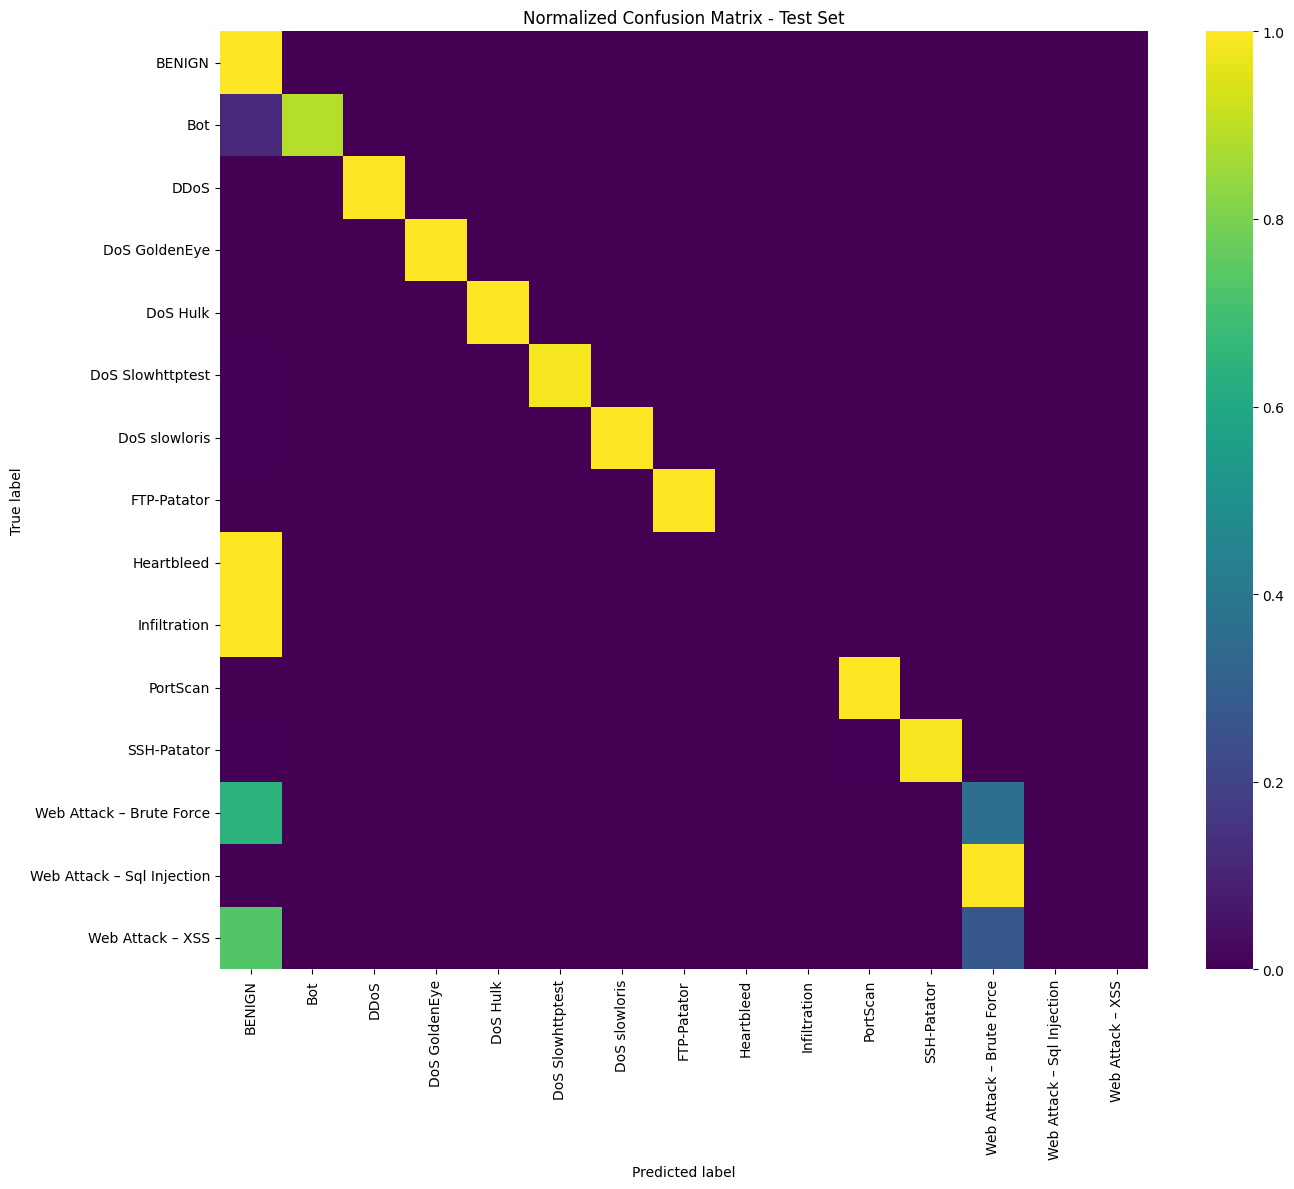

In [15]:
plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm_df, cmap="viridis", xticklabels=True, yticklabels=True)
plt.title("Normalized Confusion Matrix - Test Set")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_normalized.png", dpi=200)
plt.show()